# Example of usage
___
importing libraries and functions

In [6]:
import sys
import os

# Get current directory
current_dir = os.getcwd()
print(f"Current Directory: {current_dir}")

# Logic to find the project root
project_root = None

# Case 1: 'src' is in the current directory (Notebook is at root)
if os.path.isdir(os.path.join(current_dir, 'src')):
    project_root = current_dir

# Case 2: 'src' is one level up (Notebook is in /notebooks)
elif os.path.isdir(os.path.join(os.path.dirname(current_dir), 'src')):
    project_root = os.path.dirname(current_dir)

# Add to Python path
if project_root:
    if project_root not in sys.path:
        sys.path.append(project_root)
    print(f"Success! Added project root to path: {project_root}")
else:
    print("Error: Could not automatically find the 'src' folder. Please make sure your folder structure is correct.")

Current Directory: c:\Users\Ilidi\Documents\GitHub\L-PBF-Processing-Maps-Predictive-Analytical-Modelling\notebooks
Success! Added project root to path: c:\Users\Ilidi\Documents\GitHub\L-PBF-Processing-Maps-Predictive-Analytical-Modelling


In [7]:
import importlib
import src.data_loader as dl
import src.physics as phys
import src.plots as plots

# Optional: reload if you are editing the files
importlib.reload(dl)
importlib.reload(phys)
importlib.reload(plots)

print("Imports worked!")

Imports worked!


Loading material

In [10]:
import sys
import os
import importlib

# 1. Fix Path (Ensure notebook can see the 'src' folder)
current_dir = os.getcwd()
project_root = None

if os.path.isdir(os.path.join(current_dir, 'src')):
    project_root = current_dir
elif os.path.isdir(os.path.join(os.path.dirname(current_dir), 'src')):
    project_root = os.path.dirname(current_dir)

if project_root and project_root not in sys.path:
    sys.path.append(project_root)

# 2. Direct Imports
# This brings the functions directly into the notebook so you can use them without prefixes
from src.data_loader import load_material
from src.physics import (
    generate_process_grids, 
    check_balling_criterion, 
    check_keyhole_criterion, 
    check_lack_of_fusion_criterion,
    eagar_tsai_temperature
)
from src.plots import plot_melt_metric, plot_process_map, plot_thermal_morphology

print("Success: 'load_material' and other functions are now defined.")

# Now this should work because load_material is defined
material_file = 'Ti64.json'
beam_radius = 50e-6 
mat = load_material(material_file)

print("Material loaded:", mat['name'])

Success: 'load_material' and other functions are now defined.
Loading material from: c:\Users\Ilidi\Documents\GitHub\L-PBF-Processing-Maps-Predictive-Analytical-Modelling\materials\Ti64.json
Material loaded: Ti-6Al-4V


### Melt pool Morphology

In [13]:
# --- 3. CALCULATE DEPTH-WIDTH (Cross Section) ---
# We need to find the X location where the melt pool is deepest/widest.
# Usually this is slightly behind the laser center (x > 0).

# 1. Define the 1D line
x_centerline = np.linspace(0, 200, 100) * 1e-6

# FIX: Reshape inputs to 2D (1 row, N columns) because the function expects 2D grids
x_centerline_2d = x_centerline.reshape(1, -1)
y_zeros_2d = np.zeros_like(x_centerline_2d)
z_zeros_2d = np.zeros_like(x_centerline_2d)

# 2. Calculate Temp (Output will also be 2D)
T_center_2d = eagar_tsai_temperature(x_centerline_2d, y_zeros_2d, z_zeros_2d, P, v, mat, beam_r)

# 3. Flatten back to 1D to find the peak
T_center = T_center_2d.flatten()
x_slice = x_centerline[np.argmax(T_center)] # Slice at peak temp location

print(f"Slice taken at x = {x_slice*1e6:.2f} µm")

# 4. Generate the Cross Section Grid (This part was already correct)
YY_cross, ZZ_cross = np.meshgrid(y_range, z_range)
XX_cross = np.full_like(YY_cross, x_slice) # Constant X plane

T_cross = eagar_tsai_temperature(XX_cross, YY_cross, ZZ_cross, P, v, mat, beam_r)

Slice taken at x = 22.22 µm


Ploting meltpool dimensions as a function of processing parameters

Loading material from: c:\Users\Ilidi\Documents\GitHub\L-PBF-Processing-Maps-Predictive-Analytical-Modelling\materials\Ti64.json


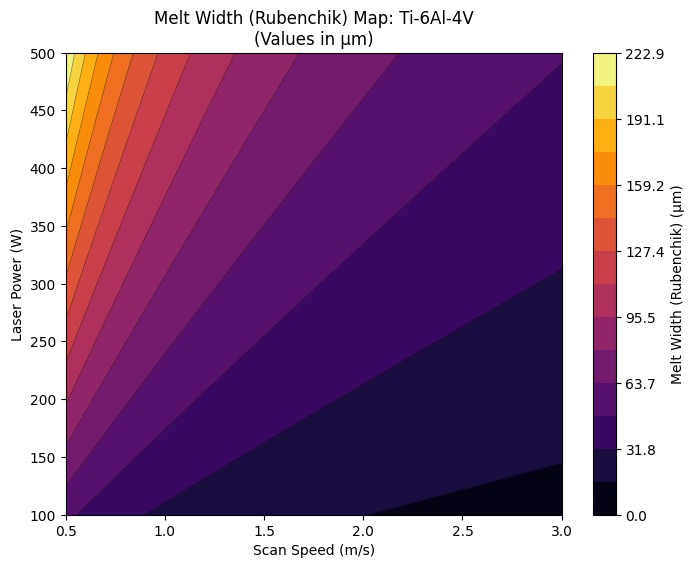

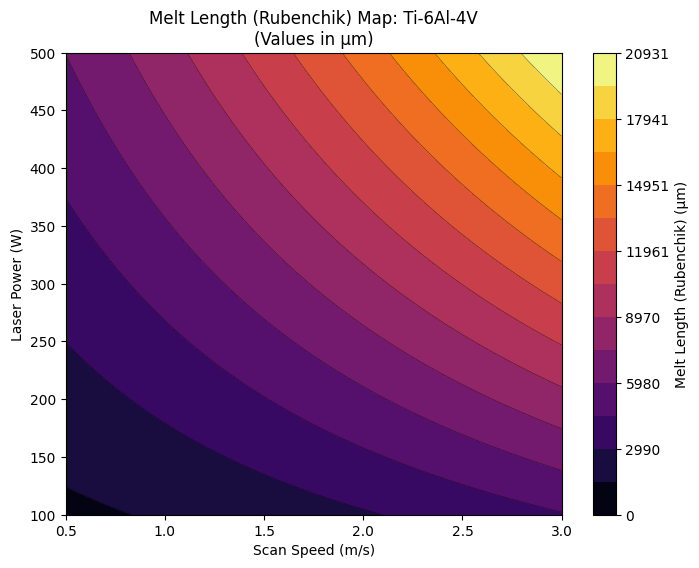

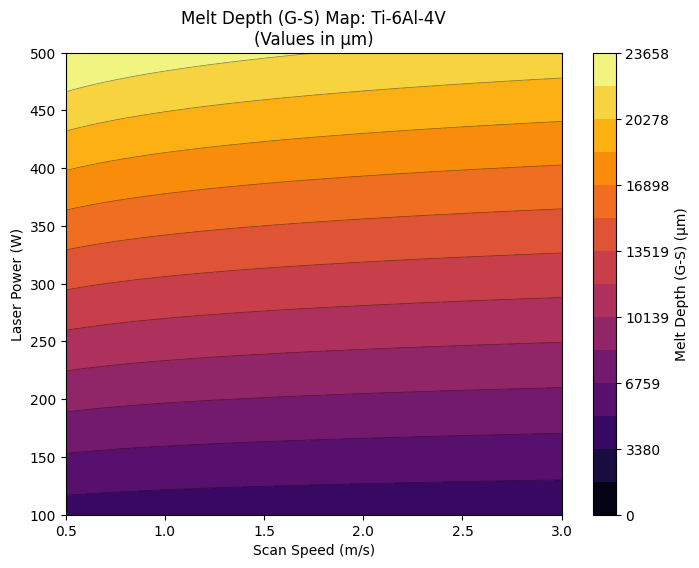

In [55]:
from src.data_loader import load_material
from src.physics import generate_process_grids
from src.plots import plot_melt_metric

# 1. Setup Parameters
mat = load_material('Ti64.json')
powers = np.linspace(100, 500, 50)
speeds = np.linspace(0.5, 3.0, 50) # Adjusted speed range for better visualization
beam_r = 50e-6

# 2. Generate Data
# Note the order of variables returned by the function!
# P, U, Depth, Width, Length, B
P_grid, U_grid, D_grid, W_grid, L_grid, B_grid = generate_process_grids(powers, speeds, mat, beam_r)

# 3. Plot Melt Width
# USE 'W_grid' HERE, NOT 'Width_grid'
fig_w = plot_melt_metric(U_grid, P_grid, W_grid, "Melt Width (Rubenchik)", mat['name'])
plt.show()

# 4. Plot Melt Length
fig_l = plot_melt_metric(U_grid, P_grid, L_grid, "Melt Length (Rubenchik)", mat['name'])
plt.show()

# 5. Plot Melt Depth (Gladush-Smurov)
fig_d = plot_melt_metric(U_grid, P_grid, D_grid, "Melt Depth (G-S)", mat['name'])
plt.show()

In [21]:
# ... (Load material, define P_grid, U_grid loops as before) ...

# After filling your Width_grid, Length_grid, Depth_grid, B_grid:

# 1. Define Machine Parameters
hatch = 100e-6 # 100 microns
layer = 30e-6  # 30 microns



# 2. Calculate Defect Masks
mask_balling = check_balling_criterion(Width_grid, Length_grid)
mask_keyhole = check_keyhole_criterion(B_grid, mat)
mask_lof     = check_lack_of_fusion_criterion(Width_grid, Depth_grid, hatch, layer)

# 3. Plot the Map
fig = plot_process_map(U_grid, P_grid, mask_balling, mask_keyhole, mask_lof, mat['name'])
plt.show()

NameError: name 'B_grid' is not defined